In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


df = pd.read_csv("/kaggle/input/wimans/annotation.csv")


In [10]:
#focusing on single user scenario for a clear learning signal
print(f"Original dataset size: {len(df)} rows")
df_single_user = df[df['number_of_users'] == 1].copy()
print(f"Filtered to {len(df_single_user)} rows with a single user.")

Original dataset size: 11286 rows
Filtered to 3564 rows with a single user.


In [11]:
#selecting the relevant columns and handle missing values
#then the activity for a single user is in user_1_activity col
df_processed = df_single_user[['label', 'user_1_activity']].dropna()

In [12]:
#rename the column for clarity
df_processed = df_processed.rename(columns={'user_1_activity': 'activity'})

In [13]:
#remove non-activity lables
#cus we only want to train the model on distinct and meaningful actions
initial_count = len(df_processed)
df_processed = df_processed[df_processed['activity'] != 'nothing']
print(f"Removed {initial_count - len(df_processed)} rows with 'nothing' activity.")

Removed 66 rows with 'nothing' activity.


In [14]:
label_encoder = LabelEncoder()
df_processed['activity_encoded'] = label_encoder.fit_transform(df_processed['activity'])

#so I created a dictionary needed for the windowing function 
labels_dict = {row['label']: row['activity_encoded'] for index, row in df_processed.iterrows()}
num_classes = len(df_processed['activity'].unique())

print(f"\nFound {num_classes} activities to classify: {list(label_encoder.classes_)}")
print("\nFirst 5 rows of the final processed DataFrame:")
print(df_processed.head())

#this file_ida list will be used in the windowing function in the next step
file_ids = df_processed['label'].tolist()


Found 8 activities to classify: ['jump', 'lie_down', 'pick_up', 'rotation', 'sit_down', 'stand_up', 'walk', 'wave']

First 5 rows of the final processed DataFrame:
     label  activity  activity_encoded
1  act_1_2      walk                 6
2  act_1_3  rotation                 3
3  act_1_4      jump                 0
4  act_1_5      wave                 7
5  act_1_6  lie_down                 1


In [15]:
df_processed.head(10)

,label,activity,activity_encoded
1,act_1_2,walk,6
2,act_1_3,rotation,3
3,act_1_4,jump,0
4,act_1_5,wave,7
5,act_1_6,lie_down,1
6,act_1_7,pick_up,2
7,act_1_8,sit_down,4
8,act_1_9,stand_up,5
10,act_1_11,walk,6
11,act_1_12,rotation,3


In [16]:
#
##step 2: Process Raw Signal Data into Windows

#this is the windowing function from what Ive said earlier
def create_windows(file_paths, labels_dict, window_size=256, step=64):
    """
    Loads CSI data, flattens it, and creates overlapping windows.
    - window_size: Number of time steps in each window (e.g., 256 samples ≈ 2.5 seconds).
    - step: How many time steps to slide the window forward (creates overlap).
    """
    X, y = [], []
    
    for file_id in file_paths:
        try:
            #load raw csi data
            csi_array = np.load(f"/kaggle/input/wimans/wifi_csi/amp/{file_id}.npy")
            
            #reshaping (timestamps,anntennas,subcarriers) -> (timestamps,features)
            csi_flattened = csi_array.reshape(csi_array.shape[0], -1)
            
            #from our dict get the label for this file
            label = labels_dict[file_id]
            
            #create overlapping windows from the flattened data
            for i in range(0, len(csi_flattened) - window_size, step):
                window = csi_flattened[i : i + window_size]
                X.append(window)
                y.append(label)
                
        except (FileNotFoundError, KeyError):
            #skip if the .npy file is missing or label not in dict
            print(f"Warning: Skipping file {file_id}.npy")
            continue
            
    return np.array(X), np.array(y)




In [17]:
#use the file_ids list from the previous step to create the dataset
#this shit takes time
X_data, y_data = create_windows(file_ids, labels_dict)

print(f"Successfully created dataset of windows.")
print(f"Shape of feature data (X): {X_data.shape}")
print(f"Shape of label data (y): {y_data.shape}")

Successfully created dataset of windows.
Shape of feature data (X): (21679, 256, 270)
Shape of label data (y): (21679,)


In [18]:
#
##step 3: Split, Normalize, and Prepare for Training

#convert labels to one-hot encoding for the model 
y_one_hot = to_categorical(y_data, num_classes=num_classes)

In [19]:
#split into training(70%),validation(15%),and test(15%) sets
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_data, y_one_hot, test_size=0.15, random_state=42, stratify=y_data)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, random_state=42, stratify=y_train_val.argmax(axis=1))

In [20]:
#
##normalize the data:fit the scaler ONLY* on the training data
scaler = StandardScaler()
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
scaler.fit(X_train_reshaped)

StandardScaler()

In [21]:
#apply the scaler to all three datasets
X_train = scaler.transform(X_train_reshaped).reshape(X_train.shape)
X_val = scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

In [22]:
print(f"\nData successfully split and normalized.")
print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")


Data successfully split and normalized.
Training set shape: (15183, 256, 270)
Validation set shape: (3244, 256, 270)
Test set shape: (3252, 256, 270)


In [23]:
#
##step 4: build train and evaluate the model

#Build the Model Architecture
#tweaking req to get better accuracy ig
input_shape = (X_train.shape[1], X_train.shape[2])
model = Sequential([
    Input(shape=input_shape),
    Conv1D(filters=64, kernel_size=16, activation='relu'),
    MaxPooling1D(pool_size=4),
    Dropout(0.4),
    LSTM(100),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


I0000 00:00:1759744722.755293      85 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759744722.756110      85 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 241, 64)        │       276,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,504 (1.36 MB)

 Trainable params: 356,504 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
#set up Early Stopping to prevent overfitting
## a cool regularisation technique: for more info https://www.geeksforgeeks.org/machine-learning/regularization-by-early-stopping/
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [25]:
# train the Model 
print("\n--- Starting Model Training ---")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping]
)
print("--- Training Complete ---")


--- Starting Model Training ---
Epoch 1/50


I0000 00:00:1759744740.068681     124 cuda_dnn.cc:529] Loaded cuDNN version 90300


238/238 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.1309 - loss: 2.1083 - val_accuracy: 0.1554 - val_loss: 2.0702
Epoch 2/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.1544 - loss: 2.0755 - val_accuracy: 0.1760 - val_loss: 2.0497
Epoch 3/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.1581 - loss: 2.0604 - val_accuracy: 0.1806 - val_loss: 2.0284
Epoch 4/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.1669 - loss: 2.0360 - val_accuracy: 0.1723 - val_loss: 2.0151
Epoch 5/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.1892 - loss: 1.9997 - val_accuracy: 0.2035 - val_loss: 1.9670
Epoch 6/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.1955 - loss: 1.9771 - val_accuracy: 0.1964 - val_loss: 1.9486
Epoch 7/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.2128 - loss: 1.9444 - val_accuracy: 0.2161 - val_loss: 1.9372
Epoch 8/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.2164 - loss: 1.9262 - val_accuracy: 0.23

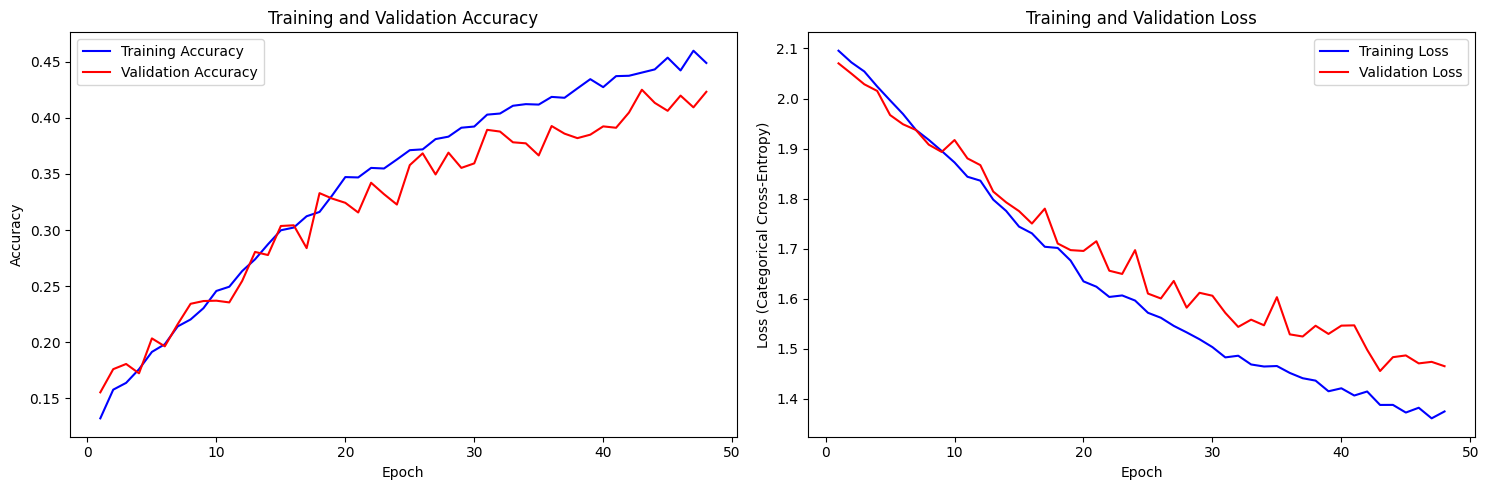

In [26]:
import matplotlib.pyplot as plt

# Assuming 'history' is the variable returned by model.fit(...)
# Example: history = model.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val))

# Get the metrics from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# Set up the figure and axes
plt.figure(figsize=(15, 5))

# --- Plot 1: Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# --- Plot 2: Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Categorical Cross-Entropy)')
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()

In [27]:

#evaluate the Model on the Unseen Test Set
print("\n--- Evaluating on Test Set ---")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.3f}")



--- Evaluating on Test Set ---
Test Accuracy: 0.414


102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


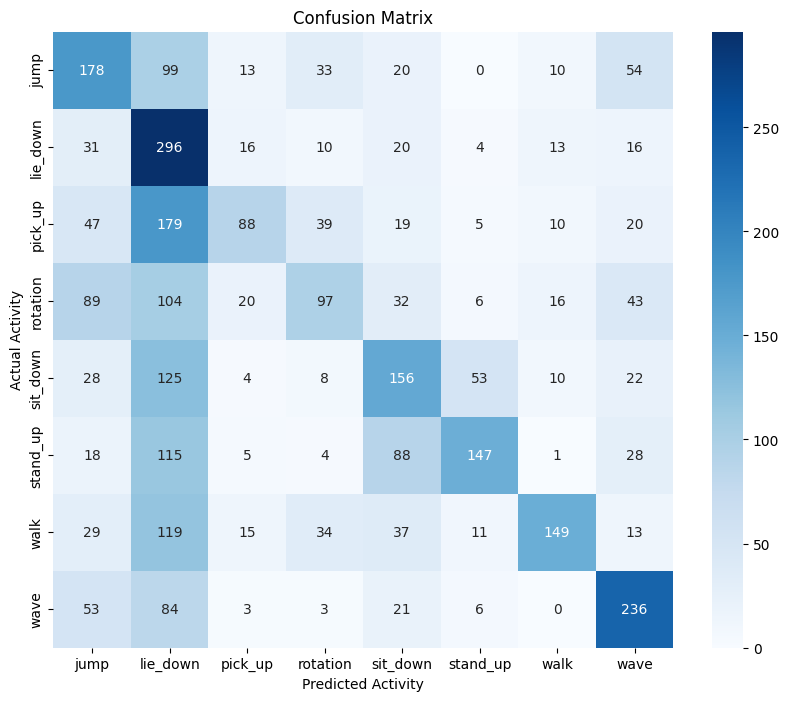


Classification Report:
              precision    recall  f1-score   support

        jump       0.38      0.44      0.40       407
    lie_down       0.26      0.73      0.39       406
     pick_up       0.54      0.22      0.31       407
    rotation       0.43      0.24      0.31       407
    sit_down       0.40      0.38      0.39       406
    stand_up       0.63      0.36      0.46       406
        walk       0.71      0.37      0.48       407
        wave       0.55      0.58      0.56       406

    accuracy                           0.41      3252
   macro avg       0.49      0.41      0.41      3252
weighted avg       0.49      0.41      0.41      3252



In [28]:

#visualize results with a Confusion Matrix
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Activity')
plt.ylabel('Actual Activity')
plt.title('Confusion Matrix')
plt.show()

#detailed classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))